# Housing Demand Prediction (Linear Regression Model)
## API Calls
to housing deprivation, immigration, housing-cost overburden, GDP per capita, population density, and unemployment rate

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(url, params = {"format": "JSON", "lang": "en"}):
    """Fetch a Eurostat dataset and return raw JSON."""
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    """Convert Eurostat JSON response to a flat DataFrame."""
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

# immigration
immigration_raw = get_stat(
    f"{EUROSTAT_BASE}/tps00176"
)

# housing deprivation
deprivation_raw = get_stat(
    f"{EUROSTAT_BASE}/sdg_11_11"
)

# overburden rate
overburden_raw = get_stat(
    f"{EUROSTAT_BASE}/ilc_lvho07a"
)

# population density
population_raw = get_stat(
    f"{EUROSTAT_BASE}/tps00003"
)

# unemployment rate
unemployment_raw = get_stat(
    f"{EUROSTAT_BASE}/tps00203"
)

# real gdp per capita
gdp_raw = get_stat(
    f"{EUROSTAT_BASE}/tipsna40"
)

df_immigration = eurostat_to_df(immigration_raw)
df_deprivation = eurostat_to_df(deprivation_raw)
df_overburden = eurostat_to_df(overburden_raw)
df_population = eurostat_to_df(population_raw)
df_unemployment = eurostat_to_df(unemployment_raw)
df_gdp = eurostat_to_df(gdp_raw)

df_immigration.to_csv("immigration.csv", index=False)
df_deprivation.to_csv("deprivation.csv", index=False)
df_overburden.to_csv("overburden.csv", index=False)
df_population.to_csv("population.csv", index=False)
df_unemployment.to_csv("unemployment.csv", index=False)
df_gdp.to_csv("gdp.csv", index=False)

## Initial Exploratory Data Analysis (EDA)

In [2]:
df_immigration = pd.read_csv("immigration.csv")
df_deprivation = pd.read_csv("deprivation.csv")
df_overburden = pd.read_csv("overburden.csv")
df_population = pd.read_csv("population.csv")
df_unemployment = pd.read_csv("unemployment.csv")
df_gdp = pd.read_csv("gdp.csv")

for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
    ("overburden", df_overburden),
    ("population", df_population),
    ("unemployment", df_unemployment),
    ("gdp", df_gdp)
]:
    print(f"=== {label} ===")
    print("shape:",   df.shape)
    print("columns:", df.columns.tolist())
    print("nulls:\n", df.isnull().sum().to_string())
    print()

=== immigration ===
shape: (1248, 9)
columns: ['freq', 'citizen', 'agedef', 'age', 'unit', 'sex', 'geo', 'time', 'value']
nulls:
 freq         0
citizen      0
agedef       0
age          0
unit         0
sex          0
geo          0
time         0
value      402

=== deprivation ===
shape: (2451, 8)
columns: ['freq', 'age', 'rskpovth', 'sex', 'unit', 'geo', 'time', 'value']
nulls:
 freq          0
age           0
rskpovth      0
sex           0
unit          0
geo           0
time          0
value       525

=== overburden ===
shape: (161874, 8)
columns: ['freq', 'unit', 'rskpovth', 'age', 'sex', 'geo', 'time', 'value']
nulls:
 freq            0
unit            0
rskpovth        0
age             0
sex             0
geo             0
time            0
value       35780

=== population ===
shape: (492, 5)
columns: ['freq', 'unit', 'geo', 'time', 'value']
nulls:
 freq      0
unit      0
geo       0
time      0
value    52

=== unemployment ===
shape: (1512, 7)
columns: ['freq', 'age', 

In [3]:
# inspect dimension values so we know how to filter each dataset
for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
    ("overburden", df_overburden),
    ("population", df_population),
    ("unemployment", df_unemployment),
    ("gdp", df_gdp)
]:
    print(f"=== {label} ===")
    for col in df.columns:
        if col not in ["value", "geo", "time"]:
            print(f"  {col}: {df[col].unique()[:8]}")
    print()

=== immigration ===
  freq: ['Annual']
  citizen: ['Total']
  agedef: ['Age reached during the year' 'Age in completed years']
  age: ['Total']
  unit: ['Number']
  sex: ['Total']

=== deprivation ===
  freq: ['Annual']
  age: ['Total']
  rskpovth: ['Total' 'Below 60%' 'Above 60%']
  sex: ['Total']
  unit: ['Percentage']

=== overburden ===
  freq: ['Annual']
  unit: ['Percentage']
  rskpovth: ['Total' 'Above 60%' 'Below 60%']
  age: ['Total' 'Less than 6 years' 'From 6 to 11 years' 'From 12 to 17 years'
 'From 15 to 19 years' 'From 15 to 24 years' 'From 15 to 29 years'
 'From 16 to 19 years']
  sex: ['Total' 'Males' 'Females']

=== population ===
  freq: ['Annual']
  unit: ['Persons per square kilometre']

=== unemployment ===
  freq: ['Annual']
  age: ['From 15 to 74 years']
  unit: ['Percentage of population in the labour force'
 'Percentage of total population' 'Thousand persons']
  sex: ['Total']

=== gdp ===
  freq: ['Annual']
  unit: ['Chain linked volumes (2015), euro per capit

## Clean Datasets

In [4]:
def clean_df(df, value_col):
    # standardise column names, drop nulls, remove EU aggregates
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[~df["geo"].str[:4].isin(["Euro", "EU27", "EU28"])]
    df["year"]    = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_immigration_clean = clean_df(df_immigration, "immigration_count")
df_deprivation_clean = clean_df(df_deprivation, "deprivation_rate")
df_overburden_clean = clean_df(df_overburden, "overburden_rate")
df_population_clean = clean_df(df_population, "population_density")
df_unemployment_clean = clean_df(df_unemployment, "unemployment_rate")
df_gdp_clean = clean_df(df_gdp, "gdp_per_capita")

# immigration: keep Total rows across all breakdown dimensions
for col in ["citizen", "sex", "age", "agedef", "unit"]:
    if col in df_immigration_clean.columns:
        vals = df_immigration_clean[col].unique()
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_immigration_clean = df_immigration_clean[
                df_immigration_clean[col] == total_val[0]
            ].copy()

# deprivation: keep Total quantile and Total household composition
for col in ["quantile", "hhcomp"]:
    if col in df_deprivation_clean.columns:
        vals = df_deprivation_clean[col].unique()
        print(f"{col} values:", vals)
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_deprivation_clean = df_deprivation_clean[
                df_deprivation_clean[col] == total_val[0]
            ].copy()

# check for year gaps
for label, df in [
    ("immigration", df_immigration_clean),
    ("deprivation", df_deprivation_clean),
    ("overburden", df_overburden_clean),
    ("population", df_population_clean),
    ("unemployment", df_unemployment_clean),
    ("gdp", df_gdp_clean)
]:
    years = sorted(df["year"].unique())
    gaps  = [y for i, y in enumerate(years[1:], 1) if y - years[i-1] > 1]
    print(f"{label}: {years[0]}-{years[-1]}, gaps: {gaps if gaps else 'none'}")

df_immigration_clean = df_immigration_clean.drop(columns = ["age", "unit", "freq"])
df_immigration_clean = df_immigration_clean[df_immigration_clean["agedef"] == "Age in completed years"]

df_deprivation_clean = df_deprivation_clean.drop(columns = ["age", "unit", "freq"])

df_overburden_clean = df_overburden_clean.drop(columns = ["unit", "freq"])
df_overburden_clean = df_overburden_clean[df_overburden_clean["age"] == "Total"]
df_overburden_clean = df_overburden_clean[df_overburden_clean["sex"] == "Total"]

df_unemployment_clean = df_unemployment_clean[df_unemployment_clean["unit"] == "Percentage of total population"]
df_unemployment_clean = df_unemployment_clean.drop(columns = ["freq", "age", "sex"])

df_gdp_clean = df_gdp_clean.drop(columns = ["freq", "unit", "na_item"])

df_population_clean = df_population_clean.drop(columns = ["freq", "unit"])

print("immigration clean:", df_immigration_clean.shape)
print("deprivation clean:", df_deprivation_clean.shape)
print("overburden clean:", df_overburden_clean.shape)
print("population clean:", df_population_clean.shape)
print("unemployment clean:", df_unemployment_clean.shape)
print("gdp clean:", df_gdp_clean.shape)

df_immigration_clean.to_csv("immigration_clean.csv", index=False)
df_deprivation_clean.to_csv("deprivation_clean.csv", index=False)
df_overburden_clean.to_csv("overburden_clean.csv", index=False)
df_population_clean.to_csv("population_clean.csv", index=False)
df_unemployment_clean.to_csv("unemployment_clean.csv", index=False)
df_gdp_clean.to_csv("gdp_clean.csv", index=False)

immigration: 2013-2024, gaps: none
deprivation: 2003-2023, gaps: [np.int64(2023)]
overburden: 2003-2025, gaps: none
population: 2013-2024, gaps: none
unemployment: 2014-2025, gaps: none
gdp: 1995-2025, gaps: none
immigration clean: (411, 6)
deprivation clean: (1752, 5)
overburden clean: (2103, 6)
population clean: (428, 3)
unemployment clean: (407, 4)
gdp clean: (832, 3)


## Data Visualizations

In [5]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_immigration_clean = pd.read_csv("immigration_clean.csv")
df_deprivation_clean = pd.read_csv("deprivation_clean.csv")
 
EXPORT_KWARGS = dict(full_html=False, include_plotlyjs="cdn")

In [6]:
# plot 1: EU average deprivation rate over time
eu_dep = df_deprivation_clean.groupby("year")["deprivation_rate"].mean().reset_index()
 
fig1 = px.line(
    eu_dep, x="year", y="deprivation_rate",
    markers=True,
    title="EU average housing deprivation rate over time",
    labels={"deprivation_rate": "Deprivation rate (%)", "year": "Year"},
    color_discrete_sequence=["#30D836"],
)
fig1.show()
# fig1.write_html("eu_avg_housing_deprivation.html", **EXPORT_KWARGS)

In [7]:
# plot 2: Housing deprivation by country (latest year)
latest_dep = (
    df_deprivation_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["deprivation_rate"].first()
    .sort_values("deprivation_rate")
)
 
fig2 = px.bar(
    latest_dep, x="deprivation_rate", y="geo", orientation="h",
    title="Housing deprivation rate by country (latest year)",
    labels={"deprivation_rate": "Deprivation rate (%)", "geo": ""},
    color_discrete_sequence=["#378ADD"],
)
fig2.update_layout(coloraxis_showscale=False)
fig2.show()
# fig2.write_html("housing_deprivation_by_country.html", **EXPORT_KWARGS)

In [8]:
# plot 3: Immigration inflow by country (latest year)
latest_immig = (
    df_immigration_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["immigration_count"].first()
    .sort_values("immigration_count")
)
 
fig3 = px.bar(
    latest_immig, x="immigration_count", y="geo", orientation="h",
    title="Immigration inflow by country (latest year)",
    labels={"immigration_count": "Number of immigrants", "geo": ""},
    color_discrete_sequence=["#AB37DD"],
)
fig3.update_layout(coloraxis_showscale=False)
fig3.show()
# fig3.write_html("immigration_by_country.html", **EXPORT_KWARGS)

In [9]:
# plot 4: EU average overburden rate over time
eu_ovb = df_overburden_clean.groupby("year")["overburden_rate"].mean().reset_index()
 
fig4 = px.line(
    eu_ovb, x="year", y="overburden_rate",
    markers=True,
    title="EU average housing cost overburden rate over time",
    labels={"overburden_rate": "Overburden rate (%)", "year": "Year"},
    color_discrete_sequence=["#378ADD"],
)
fig4.show()
# fig4.write_html("eu_avg_overburden.html", **EXPORT_KWARGS)

In [10]:
# plot 5: Overburden rate by country (latest year)
latest_ovb = (
    df_overburden_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["overburden_rate"].first()
    .sort_values("overburden_rate")
)
 
fig5 = px.bar(
    latest_ovb, x="overburden_rate", y="geo", orientation="h",
    title="Housing cost overburden rate by country (latest year)",
    labels={"overburden_rate": "Overburden rate (%)", "geo": ""},
    color_discrete_sequence=["#DD3798"],
)
fig5.update_layout(coloraxis_showscale=False)
fig5.show()
# fig5.write_html("overburden_by_country.html", **EXPORT_KWARGS)

In [11]:
# plot 6: EU average unemployment rate over time
eu_unemp = df_unemployment_clean.groupby("year")["unemployment_rate"].mean().reset_index()
 
fig6 = px.line(
    eu_unemp, x="year", y="unemployment_rate",
    markers=True,
    title="EU average unemployment rate over time",
    labels={"unemployment_rate": "Unemployment rate (%)", "year": "Year"},
    color_discrete_sequence=["#E63946"],
)
fig6.show()
# fig6.write_html("eu_avg_unemployment.html", **EXPORT_KWARGS)

In [12]:
# plot 7: GDP per capita by country (latest year)
latest_gdp = (
    df_gdp_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["gdp_per_capita"].first()
    .sort_values("gdp_per_capita")
)
 
fig7 = px.bar(
    latest_gdp, x="gdp_per_capita", y="geo", orientation="h",
    title="Real GDP per capita by country (latest year)",
    labels={"gdp_per_capita": "GDP per capita (€)", "geo": ""},
    color_discrete_sequence=["#3F37DD"],
)
fig7.update_layout(coloraxis_showscale=False)
fig7.show()
# fig7.write_html("gdp_by_country.html", **EXPORT_KWARGS)

In [13]:
# plot 8: Population density by country (latest year)
latest_pop = (
    df_population_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["population_density"].first()
    .sort_values("population_density")
)
 
fig8 = px.bar(
    latest_pop, x="population_density", y="geo", orientation="h",
    title="Population density by country (latest year)",
    labels={"population_density": "Population density (per km²)", "geo": ""},
    color_discrete_sequence=["#DD3737"],
)
fig8.update_layout(coloraxis_showscale=False)
fig8.show()
# fig8.write_html("population_density_by_country.html", **EXPORT_KWARGS)

## Aggregate, Feature Engineering, and Merge

In [14]:
# drop constant dimension columns (all filtered to Total already)
df_deprivation_clean = df_deprivation_clean.drop(columns=["hhcomp"], errors="ignore")
df_deprivation_clean = df_deprivation_clean.drop(columns=["quantile"], errors="ignore")

# merge datasets: start from target, join features on geo + year
merged = df_deprivation_clean.merge(df_immigration_clean, on=["geo", "year", "sex"])
merged = merged.merge(df_overburden_clean, on=["geo", "year", "rskpovth"])
merged = merged.merge(df_gdp_clean, on=["geo", "year"])
merged = merged.merge(df_population_clean, on=["geo", "year"])
merged = merged.merge(df_unemployment_clean, on=["geo", "year"])

merged = merged.dropna()
print(f"Merged: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
merged.to_csv("merged_linreg.csv", index=False)


Merged: 642 rows, 27 countries


In [15]:
# correlation heatmap to check for multicollinearity and get a sense of feature relationships
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv("merged_linreg.csv")
corr = df[["immigration_count", "overburden_rate", "gdp_per_capita", "population_density", "unemployment_rate"]].corr()
labels = ["Immigration", "Overburden", "GDP", "Density", "Unemployment"]

fig3 = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=labels,
    y=labels,
    colorscale='RdYlGn',
    zmid=0,
    text=np.round(corr.values, 2),
    texttemplate='%{text}',
    hovertemplate='%{x} vs %{y}: %{z:.2f}<extra></extra>',
))
fig3.update_layout(title='Correlation heatmap')
fig3.show()


In [16]:
# feature engineering (interaction terms)
df['density_unemployment'] = df['population_density'] * df['unemployment_rate']
df['gdp_unemployment'] = df['gdp_per_capita'] * df['unemployment_rate']
df['density_overburden'] = df['population_density'] * df['overburden_rate']

df.to_csv("merged_linreg.csv", index=False)

## Linear Regression Model

**Features (X):**
- immigration_count
- overburden_rate
- gdp_per_capita
- population_density
- unemployment_rate

**Target (y):** deprivation_rate

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("merged_linreg.csv")

continuous_cols = ["immigration_count", "overburden_rate", "gdp_per_capita", "population_density", "unemployment_rate", 
                   "density_unemployment", "gdp_unemployment", "density_overburden"]

dummy_cols = [c for c in df.columns if c.startswith("country_")]

target_col = "deprivation_rate"

X_continuous = df[continuous_cols].to_numpy()
X_dummies    = df[dummy_cols].to_numpy().astype(float)
y            = df[target_col].to_numpy()

(
    X_cont_train, X_cont_test,
    X_dum_train,  X_dum_test,
    y_train,      y_test
) = train_test_split(
    X_continuous, X_dummies, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_cont_train_scaled = scaler.fit_transform(X_cont_train)
X_cont_test_scaled  = scaler.transform(X_cont_test)

X_train = np.hstack([X_cont_train_scaled, X_dum_train])
X_test  = np.hstack([X_cont_test_scaled,  X_dum_test])

# deprivation_rate is a bounded percentage (>= 0) that is skewed toward 0, so plain
# OLS can predict negative rates. Train the model on log1p(rate) instead: the model
# lives in unbounded log-space, and expm1 maps predictions back to a non-negative
# rate. log1p (= log(1 + x)) is used so that a true rate of 0 maps cleanly to 0.
y_train_log = np.log1p(y_train)

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Features: {X_train.shape[1]} ({len(continuous_cols)} continuous + {len(dummy_cols)} country dummies)")

Train: 449 rows, Test: 193 rows
Features: 8 (8 continuous + 0 country dummies)


In [18]:
def my_linear_regression(X_train, y_train, X_test):
    """
    Linear regression using the closed-form normal equation.
    Solves: w = (X^T X)^{-1} X^T y

    Args:
        X_train: numpy array (n_samples, n_features)
        y_train: numpy array (n_samples,)
        X_test:  numpy array (m_samples, n_features)

    Returns:
        y_pred:  numpy array (m_samples,) - predictions (in the same space as y_train)
        weights: numpy array (n_features + 1,) - [intercept, coef1, coef2, ...]
    """
    n = X_train.shape[0]
    X_b = np.column_stack([np.ones(n), X_train])

    weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_train

    m = X_test.shape[0]
    X_test_b = np.column_stack([np.ones(m), X_test])
    y_pred = X_test_b @ weights

    return y_pred, weights

# fit on the log-transformed target, then map predictions back to rate space with
# expm1 (the inverse of log1p). expm1 is always > -1, so predicted rates are >= 0.
y_pred_log, weights = my_linear_regression(X_train, y_train_log, X_test)
y_pred = np.expm1(y_pred_log)

print("Continuous feature coefficients (log-rate space, after scaling):")
labels = ["intercept"] + continuous_cols
for label, w in zip(labels, weights[:len(labels)]):
    print(f"  {label:25s}: {w:.4f}")

Continuous feature coefficients (log-rate space, after scaling):
  intercept                : 1.7047
  immigration_count        : -0.1010
  overburden_rate          : 0.4538
  gdp_per_capita           : -0.0298
  population_density       : -0.3802
  unemployment_rate        : -0.0255
  density_unemployment     : 0.2043
  gdp_unemployment         : -0.3839
  density_overburden       : -0.0620


In [19]:
# success metrics
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"R2:   {r2:.4f}")

MSE:  24.5074
R2:   0.4290


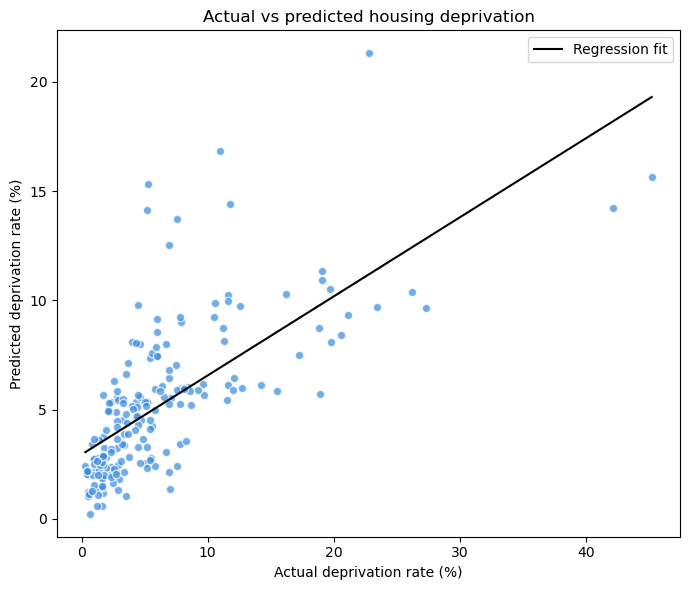

In [20]:
# plot 9: actual vs predicted deprivation rate

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.7, color="#378ADD", edgecolors="white")
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
m, c = np.polyfit(y_test, y_pred, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, m * x_line + c,
         color='black', linewidth=1.5, label='Regression fit')
ax.set_xlabel("Actual deprivation rate (%)")
ax.set_ylabel("Predicted deprivation rate (%)")
ax.set_title("Actual vs predicted housing deprivation")
ax.legend()
plt.tight_layout()
plt.show()

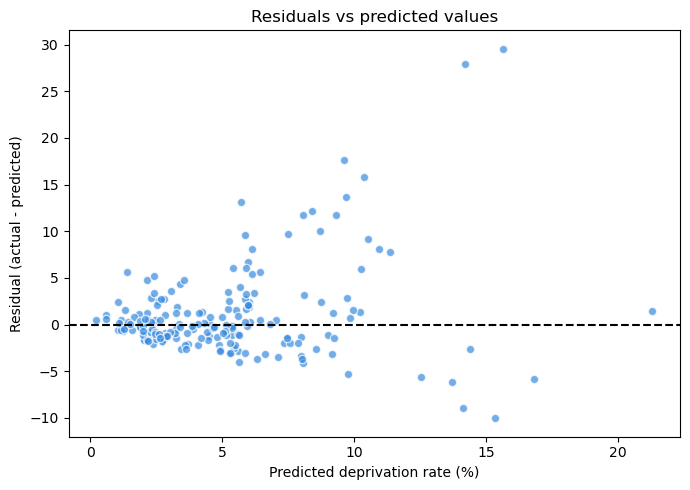

In [21]:
# plot 10: residuals

residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.7, color="#378ADD", edgecolors="white")
ax.axhline(0, color="#000000", linestyle="--")
ax.set_xlabel("Predicted deprivation rate (%)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs predicted values")
plt.tight_layout()
plt.show()

## Interpret and Apply the Model

In [22]:
# predicted deprivation for the most recent year per country
latest = (
    df.sort_values("year", ascending=False)
    .groupby("geo", as_index=False)
    .first()
)

X_latest_cont = scaler.transform(latest[continuous_cols].to_numpy())
X_latest_dum  = latest[dummy_cols].to_numpy().astype(float)
X_latest      = np.hstack([X_latest_cont, X_latest_dum])

n_latest   = X_latest.shape[0]
X_latest_b = np.column_stack([np.ones(n_latest), X_latest])
# weights are in log-rate space, so back-transform with expm1 to get a non-negative rate
latest["predicted_deprivation"] = np.expm1(X_latest_b @ weights)

result = (
    latest[["geo", "year", "deprivation_rate", "predicted_deprivation"]]
    .sort_values("predicted_deprivation", ascending=False)
)
print("Countries ranked by predicted deprivation (highest = most need for ESF+ funding):")
print(result.to_string(index=False))

Countries ranked by predicted deprivation (highest = most need for ESF+ funding):
        geo  year  deprivation_rate  predicted_deprivation
   Slovakia  2023              15.2              11.769729
    Romania  2023              26.2              10.378821
     Poland  2023               8.0              10.301158
   Slovenia  2023               8.5               8.424177
     Greece  2023               6.9               7.773748
    Austria  2023              14.2               7.010385
   Bulgaria  2023               3.5               6.625992
   Portugal  2023              14.8               6.526582
    Hungary  2023               3.6               5.700585
    Czechia  2023               1.7               5.656849
    Croatia  2023               2.8               5.595363
     Latvia  2023              10.2               5.248103
    Estonia  2023               2.4               4.674613
  Lithuania  2023               3.9               4.574901
    Finland  2023               3

In [23]:
# plot 11: predicted deprivation by country
fig7 = px.bar(
    result.sort_values("predicted_deprivation"),
    x="predicted_deprivation", y="geo", orientation="h",
    title="Predicted housing deprivation by country",
    labels={"predicted_deprivation": "Predicted deprivation rate (%)", "geo": ""}, color_discrete_sequence=["#ED0F52"]
)
fig7.show()
# fig7.write_html('predicted_housing_deprivation_by_country.html', full_html=False, include_plotlyjs='cdn')